# 비트코인 가격 방향 예측

머신러닝으로 비트코인이 다음 날 오를지 내릴지를 예측하고, 실제 매매에 썼을 때
수익이 나는지 확인합니다.

## 무엇을 볼 것인가

예측 정확도만 보면 안 됩니다. **거래에는 수수료와 슬리피지가 들기 때문**입니다.
방향을 맞혀도 그 폭이 비용보다 작으면 손해입니다.

그래서 두 가지를 함께 봅니다.

- **손익분기 정확도** — 몇 % 이상 맞혀야 본전인가
- **실제 수익률** — 그대로 매매하면 얼마를 벌거나 잃는가

## 손익분기 계산

$$p^* = \frac{손실폭 + 비용}{이익폭 + 손실폭}$$

이기는 폭과 지는 폭이 같다면 비용만큼만 더 맞히면 됩니다. 그런데 실제로는
폭이 다를 수 있어서 이렇게 계산합니다.

## 비용 가정

업비트 수수료는 편도 0.05%입니다. 사고팔면 왕복 0.10%죠.

슬리피지는 주문이 호가창을 얼마나 먹느냐에 따라 달라지는데, **지정가 주문이면
거의 없습니다.** 여기서는 왕복 0.10%(수수료만)를 기본으로 잡고, 나중에 비용을
바꿔가며 얼마까지 견디는지 확인하겠습니다.

## 비교 기준

**그냥 사서 들고 있는 것**과 비교합니다. 모델이 이것보다 못하면 의미가 없습니다.

데이터
  KRW-BTC : 2,057일  (2021-01-01 ~ 2026-08-19)

손익분기 정확도

  오른 날 평균 : +1.77%
  내린 날 평균 : -1.67%
  상승 비율    : 50.0%
  왕복 비용    : 0.10%

  손익분기 : 51.43%

비교 기준 — 그냥 보유했을 때

  전체 수익률 : +195.2%
  연평균      : +21.2%
  최대 낙폭   : -74.1%
  샤프 비율   : 0.39


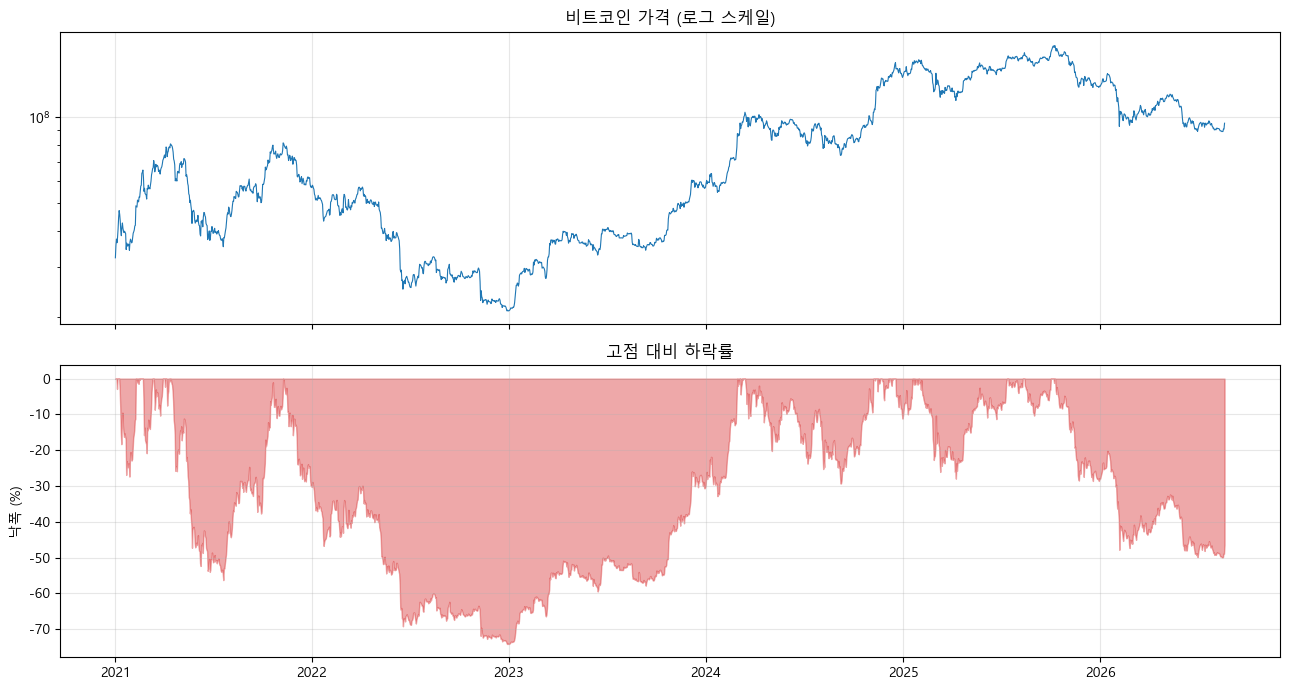

In [83]:
# ===== 셀 1 =====
# 설정 및 손익분기 계산

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
mpl.rc("font", family="Malgun Gothic")
mpl.rc("axes", unicode_minus=False)

BASE_DIR  = Path.cwd()
CLEAN_DIR = BASE_DIR / "data" / "clean"

TARGET  = "KRW-BTC"
HORIZON = 1                    # 다음 날 방향

# ── 거래 비용 ───────────────────────────────────────────
FEE_ONE_WAY = 0.0005           # 업비트 편도 0.05%
COST_ROUND  = FEE_ONE_WAY * 2  # 왕복 0.10%

# ── 검증 설정 ───────────────────────────────────────────
TRAIN_DAYS = 365
TEST_DAYS  = 90
STEP_DAYS  = 90
PURGE_DAYS = HORIZON

# ── 데이터 ──────────────────────────────────────────────
btc = pd.read_parquet(CLEAN_DIR / f"{TARGET}_1d.parquet")
c = btc["close"]

print("데이터")
print(f"  {TARGET} : {len(btc):,}일  "
      f"({btc.index[0]:%Y-%m-%d} ~ {btc.index[-1]:%Y-%m-%d})")

# ── 손익분기 ────────────────────────────────────────────
r = np.log(c.shift(-HORIZON) / c).dropna()
win  = r[r > 0].mean()
loss = -r[r < 0].mean()
BREAKEVEN = (loss + COST_ROUND) / (win + loss)

print("\n" + "=" * 60)
print("손익분기 정확도")
print("=" * 60)
print(f"\n  오른 날 평균 : {win*100:+.2f}%")
print(f"  내린 날 평균 : {-loss*100:+.2f}%")
print(f"  상승 비율    : {(r > 0).mean()*100:.1f}%")
print(f"  왕복 비용    : {COST_ROUND*100:.2f}%")
print(f"\n  손익분기 : {BREAKEVEN*100:.2f}%")

# ── Buy & Hold ──────────────────────────────────────────
total  = c.iloc[-1] / c.iloc[0]
years  = (btc.index[-1] - btc.index[0]).days / 365
cagr   = total ** (1/years) - 1
dd     = c / c.cummax() - 1
daily  = np.log(c / c.shift(1)).dropna()
sharpe = daily.mean() / daily.std() * np.sqrt(365)

print("\n" + "=" * 60)
print("비교 기준 — 그냥 보유했을 때")
print("=" * 60)
print(f"\n  전체 수익률 : {(total-1)*100:+.1f}%")
print(f"  연평균      : {cagr*100:+.1f}%")
print(f"  최대 낙폭   : {dd.min()*100:.1f}%")
print(f"  샤프 비율   : {sharpe:.2f}")

BH = {"cagr": cagr, "mdd": dd.min(), "sharpe": sharpe,
      "cum": total - 1}

# ── 그래프 ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(c.index, c, lw=0.8, color="tab:blue")
axes[0].set_yscale("log")
axes[0].set_title("비트코인 가격 (로그 스케일)")
axes[0].grid(alpha=0.3)

axes[1].fill_between(c.index, dd*100, 0, color="tab:red", alpha=0.4)
axes[1].set_ylabel("낙폭 (%)")
axes[1].set_title("고점 대비 하락률")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 손익분기 계산 결과

| 항목 | 값 |
|---|---|
| 오른 날 평균 | +1.77% |
| 내린 날 평균 | -1.67% |
| 상승 비율 | 50.0% |
| 왕복 비용 | 0.10% |
| **손익분기** | **51.43%** |

**51.43%를 넘겨야 본전**입니다. 비용을 0.20%로 잡으면 54.34%가 되는데,
지정가 주문으로 슬리피지를 없애면 3%p 가까이 내려갑니다.

다만 여유가 크지 않습니다. 슬리피지가 편도 0.04%만 생겨도 손익분기가 53.7%로
올라갑니다. **이 전략이 비용에 얼마나 민감한지는 나중에 따로 확인**하겠습니다.

상승 비율이 정확히 50.0%인 점도 눈에 띕니다. 5년 반 동안 195% 올랐는데 일
단위로는 반반입니다. **큰 상승이 소수의 날에 몰려 있다**는 뜻이고, 맞히는
횟수보다 언제 맞히느냐가 더 중요할 수 있습니다.

### 비교 기준

| 지표 | 값 |
|---|---|
| 전체 수익률 | +195.2% |
| 연평균 | +21.2% |
| 최대 낙폭 | -74.1% |
| 샤프 비율 | 0.39 |

그냥 보유만 해도 연 21%입니다. 모델이 이것을 넘지 못하면 의미가 없습니다.
다만 최대 낙폭이 -74%로 매우 큽니다. 샤프 0.39는 위험 대비 수익이 낮다는
뜻입니다.

## 2. 지표 만들기

여섯 그룹의 지표를 만듭니다. 각 그룹이 시장을 다른 각도로 봅니다.

| 그룹 | 무엇을 보나 | 예시 |
|---|---|---|
| 추세 | 방향이 잡혔는가 | MACD, ADX |
| 모멘텀 | 과열인가 침체인가 | RSI, 스토캐스틱 |
| 변동성 | 얼마나 출렁이는가 | 볼린저밴드, ATR |
| 거래량 | 자금이 들어오는가 | OBV, MFI |
| 거래량 진위 | 그 거래량이 진짜인가 | 종가 위치 × 거래량 |
| 온체인 | 네트워크에서 일어나는 일 | 활성 주소, 채굴자 수익 |

### 온체인을 넣는 이유

앞의 다섯 그룹은 전부 가격과 거래량에서 나옵니다. **누구나 보는 정보**라 이미
가격에 반영됐을 가능성이 큽니다.

온체인은 다릅니다. 블록체인에 기록되는 활성 주소 수, 채굴자 수익, 해시레이트
같은 것들인데, **거래소 밖에서 일어나는 일**이라 아직 덜 반영됐을 수 있습니다.

### 거래량 진위를 따로 보는 이유

암호화폐 거래소는 허위 거래로 거래량을 부풀리는 경우가 있습니다. 그리고
**양봉이어도 매도세가 강할 수 있습니다.** 장중에 올랐다가 밀려서 겨우 양봉으로
끝났다면 매도 압력이 컸다는 뜻이죠.

종가가 고저 범위 어디쯤에 있는지에 거래량을 곱하면 이런 것이 보입니다.

### 시점 주의

온체인 데이터는 UTC 기준으로 집계되는데 업비트 일봉은 09시(KST) 마감입니다.
같은 날 값을 쓰면 시점이 겹칠 수 있어서 **하루 밀어서** 씁니다.

수집할 때도 주의가 필요했습니다. blockchain.com API는 긴 기간을 한 번에
요청하면 2일 간격으로 샘플링해서 줍니다. **2년씩 나눠 요청**해야 일 단위로
받을 수 있었습니다.

In [84]:
# ===== 셀 2 =====
# 지표 생성

import requests, time

o, h, l = btc["open"], btc["high"], btc["low"]
v, val = btc["volume"], btc["value"]
ret = np.log(c / c.shift(1))

df = pd.DataFrame(index=btc.index)

# ══ 1. 추세 ═════════════════════════════════════════════
ema12, ema26 = c.ewm(span=12).mean(), c.ewm(span=26).mean()
macd = ema12 - ema26
df["macd_norm"] = macd / c
df["macd_hist"] = (macd - macd.ewm(span=9).mean()) / c
df["ema_cross"] = c.ewm(span=10).mean() / c.ewm(span=30).mean() - 1

up_m, dn_m = h.diff(), -l.diff()
plus_dm  = np.where((up_m > dn_m) & (up_m > 0), up_m, 0)
minus_dm = np.where((dn_m > up_m) & (dn_m > 0), dn_m, 0)
tr_ = pd.concat([h-l, (h-c.shift()).abs(), (l-c.shift()).abs()],
                axis=1).max(axis=1)
atr14 = tr_.rolling(14).mean()
pdi = 100 * pd.Series(plus_dm, index=c.index).rolling(14).mean() / atr14
mdi = 100 * pd.Series(minus_dm, index=c.index).rolling(14).mean() / atr14
df["adx"] = (100*(pdi-mdi).abs()/(pdi+mdi).replace(0, np.nan)).rolling(14).mean()
df["di_diff"] = pdi - mdi

TREND = ["macd_norm", "macd_hist", "ema_cross", "adx", "di_diff"]

# ══ 2. 모멘텀 ═══════════════════════════════════════════
delta = c.diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss_ = (-delta.clip(upper=0)).rolling(14).mean()
df["rsi_14"] = 100 - 100/(1 + gain/loss_.replace(0, np.nan))

lo14, hi14 = l.rolling(14).min(), h.rolling(14).max()
df["stoch_k"] = 100*(c-lo14)/(hi14-lo14).replace(0, np.nan)
df["stoch_d"] = df["stoch_k"].rolling(3).mean()

tp = (h+l+c)/3
df["cci"] = (tp - tp.rolling(20).mean())/(0.015*tp.rolling(20).std())
df["roc_10"] = np.log(c/c.shift(10))
df["williams_r"] = -100*(hi14-c)/(hi14-lo14).replace(0, np.nan)

MOMENTUM = ["rsi_14", "stoch_k", "stoch_d", "cci", "roc_10", "williams_r"]

# ══ 3. 변동성 ═══════════════════════════════════════════
ma20, sd20 = c.rolling(20).mean(), c.rolling(20).std()
df["bb_width"] = 4*sd20/ma20
df["bb_pct"]   = (c - (ma20-2*sd20))/(4*sd20)
df["atr_norm"] = atr14/c
df["vol_20"]   = ret.rolling(20).std()
df["vol_ratio_5_20"] = ret.rolling(5).std()/ret.rolling(20).std()

VOLATILITY = ["bb_width", "bb_pct", "atr_norm", "vol_20", "vol_ratio_5_20"]

# ══ 4. 거래량 ═══════════════════════════════════════════
obv = (np.sign(c.diff())*v).fillna(0).cumsum()
df["obv_slope"] = (obv - obv.rolling(20).mean())/v.rolling(20).mean()/20

mf = tp*v
pmf = mf.where(tp > tp.shift(1), 0).rolling(14).sum()
nmf = mf.where(tp < tp.shift(1), 0).rolling(14).sum()
df["mfi"] = 100 - 100/(1 + pmf/nmf.replace(0, np.nan))

df["vol_ratio"]   = v/v.rolling(20).mean()
df["value_ratio"] = val/val.rolling(20).mean()
vwap20 = (tp*v).rolling(20).sum()/v.rolling(20).sum()
df["vwap_dist"] = (c - vwap20)/vwap20

VOLUME = ["obv_slope", "mfi", "vol_ratio", "value_ratio", "vwap_dist"]

# ══ 5. 거래량 진위 ══════════════════════════════════════
rng_ = (h-l).replace(0, np.nan)
close_pos = (c-l)/rng_                       # 종가가 고저 범위 어디쯤

df["buy_pressure"]  = close_pos * v/v.rolling(20).mean()
df["sell_pressure"] = (1-close_pos) * v/v.rolling(20).mean()
df["pressure_diff"] = df["buy_pressure"] - df["sell_pressure"]
df["fake_bull"] = (c>o).astype(int) * (0.5-close_pos).clip(lower=0) \
                  * (v/v.rolling(20).mean())
df["upper_wick_vol"] = ((h-np.maximum(c,o))/rng_) * (v/v.rolling(20).mean())
df["amihud"] = (ret.abs()/(val/1e9)).rolling(10).mean()
df["vol_price_div"] = v/v.rolling(20).mean() - \
                      ret.abs()/ret.abs().rolling(20).mean()

AUTHENTICITY = ["buy_pressure", "sell_pressure", "pressure_diff",
                "fake_bull", "upper_wick_vol", "amihud", "vol_price_div"]

# ══ 6. 온체인 ═══════════════════════════════════════════
CHARTS = ["n-unique-addresses", "n-transactions", "hash-rate",
          "miners-revenue", "cost-per-transaction",
          "estimated-transaction-volume-usd", "output-volume", "market-cap"]

def fetch(chart, n=4):
    """2년씩 나눠 요청 (한 번에 받으면 2일 간격으로 샘플링됨)"""
    fr = []
    for i in range(n):
        st = pd.Timestamp("2026-08-20") - pd.DateOffset(years=2*(i+1))
        url = (f"https://api.blockchain.info/charts/{chart}"
               f"?timespan=2years&start={st:%Y-%m-%d}&format=json")
        try:
            rj = requests.get(url, timeout=30).json()
            if rj.get("values"):
                s = pd.DataFrame(rj["values"])
                s["date"] = pd.to_datetime(s["x"], unit="s").dt.normalize()
                fr.append(s.set_index("date")["y"])
        except Exception:
            pass
        time.sleep(0.3)
    if not fr:
        return None
    out = pd.concat(fr).sort_index()
    return out[~out.index.duplicated(keep="last")]

print("온체인 수집 중...")
oc_raw = {}
for ch in CHARTS:
    s = fetch(ch)
    if s is not None and len(s) > 1000:
        full = pd.date_range(s.index[0], s.index[-1], freq="D")
        oc_raw[ch] = s.reindex(full).ffill()
        print(f"  {ch:36s} {len(s):,}일")

oc = pd.DataFrame(oc_raw)
oc_a = oc.reindex(btc.index.normalize())
oc_a.index = btc.index
oc_a = oc_a.shift(1)                          # 하루 밀기

addr, tx = oc_a["n-unique-addresses"], oc_a["n-transactions"]
hr, mrev = oc_a["hash-rate"], oc_a["miners-revenue"]
tvol, mcap = oc_a["estimated-transaction-volume-usd"], oc_a["market-cap"]

df["addr_dist30"]  = addr/addr.rolling(30).mean() - 1
df["tx_dist30"]    = tx/tx.rolling(30).mean() - 1
df["hash_ribbon"]  = hr.rolling(30).mean()/hr.rolling(60).mean() - 1
df["miner_dist90"] = mrev/mrev.rolling(90).mean() - 1
df["miner_chg7"]   = np.log(mrev/mrev.shift(7))
nvt = mcap/tvol.rolling(7).mean()
df["nvt_z90"] = (nvt - nvt.rolling(90).mean())/nvt.rolling(90).std()

ONCHAIN = ["addr_dist30", "tx_dist30", "hash_ribbon",
           "miner_dist90", "miner_chg7", "nvt_z90"]

# ══ 라벨 ════════════════════════════════════════════════
df["y"] = (np.log(c.shift(-HORIZON)/c) > 0).astype(int)
df["fwd_ret"] = np.log(c.shift(-HORIZON)/c)
df["close"] = c

GROUPS = {"추세": TREND, "모멘텀": MOMENTUM, "변동성": VOLATILITY,
          "거래량": VOLUME, "거래량진위": AUTHENTICITY, "온체인": ONCHAIN}
ALL_F = sum(GROUPS.values(), [])

data = df.dropna(subset=ALL_F + ["y"]).copy()

print("\n" + "=" * 66)
print("데이터셋")
print("=" * 66)
print(f"\n  표본 : {len(data):,}일  "
      f"({data.index[0]:%Y-%m-%d} ~ {data.index[-1]:%Y-%m-%d})")
print(f"  상승 비율 : {data['y'].mean()*100:.1f}%\n")
for g, f_ in GROUPS.items():
    print(f"  {g:10s} : {len(f_):2d}개")
print(f"  {'합계':10s} : {len(ALL_F):2d}개")

# ── 미래 정보 점검 ──────────────────────────────────────
print("\n" + "=" * 66)
print("미래 정보가 섞이지 않았는가")
print("=" * 66)

mx_ac = max(data[f].autocorr(1) for f in ALL_F)
corrs = {f: data[f].corr(data["y"]) for f in ALL_F}
mx_c  = max(abs(v) for v in corrs.values())

raw_addr = oc["n-unique-addresses"].reindex(data.index.normalize())
raw_addr.index = data.index
same_day = (df["addr_dist30"].reindex(data.index) ==
            (raw_addr/raw_addr.rolling(30).mean()-1)).mean()

print(f"\n  피처 자기상관 최대   : {mx_ac:.4f}  "
      f"({'정상' if mx_ac < 0.9999 else '확인필요'})")
print(f"  정답과 상관 최대     : {mx_c:.4f}  "
      f"({'정상' if mx_c < 0.3 else '확인필요'})")
print(f"  온체인 같은날 일치율 : {same_day*100:.1f}%  "
      f"({'하루 밀림 확인' if same_day < 0.1 else '재확인 필요'})")

# ── 그룹별 최고 상관 ────────────────────────────────────
print("\n" + "=" * 66)
print("그룹별 정답과의 상관 (상위 2개)")
print("=" * 66)

for g, f_ in GROUPS.items():
    top = sorted({x: corrs[x] for x in f_}.items(),
                 key=lambda x: -abs(x[1]))[:2]
    print(f"  {g:10s} : " + "  ".join(f"{a} {b:+.4f}" for a, b in top))

온체인 수집 중...
  n-unique-addresses                   2,912일
  n-transactions                       2,916일
  hash-rate                            2,916일
  miners-revenue                       2,919일
  cost-per-transaction                 2,919일
  estimated-transaction-volume-usd     2,914일
  output-volume                        2,920일
  market-cap                           2,920일

데이터셋

  표본 : 1,959일  (2021-04-07 ~ 2026-08-17)
  상승 비율 : 49.7%

  추세         :  5개
  모멘텀        :  6개
  변동성        :  5개
  거래량        :  5개
  거래량진위      :  7개
  온체인        :  6개
  합계         : 34개

미래 정보가 섞이지 않았는가

  피처 자기상관 최대   : 0.9951  (정상)
  정답과 상관 최대     : 0.0371  (정상)
  온체인 같은날 일치율 : 0.0%  (하루 밀림 확인)

그룹별 정답과의 상관 (상위 2개)
  추세         : di_diff +0.0206  macd_hist -0.0187
  모멘텀        : rsi_14 +0.0182  cci +0.0161
  변동성        : bb_width +0.0287  vol_ratio_5_20 -0.0188
  거래량        : value_ratio +0.0311  vol_ratio +0.0291
  거래량진위      : upper_wick_vol +0.0371  sell_pressure +0.0324
  온체인        : nvt_z90 -0

### 지표 생성 결과

표본 1,959일, 지표 34개를 6그룹으로 나눴습니다.

**미래 정보 점검을 세 가지로 했고 모두 통과**했습니다.

- 피처 자기상관 최대 0.9951 (정확히 1.0이 아님)
- 정답과의 상관 최대 0.0371 (기준 0.3)
- 온체인 데이터가 같은 날 값과 0.0% 일치 → 하루 밀림 확인

세 번째가 특히 중요합니다. 외부 데이터를 쓸 때 시점이 겹치면 미래를 미리 아는
셈이 되는데, 이것이 차단됐음을 확인했습니다.

### 그룹별 예측력

| 그룹 | 최고 지표 | 상관 |
|---|---|---|
| **거래량진위** | upper_wick_vol | **+0.0371** |
| 거래량 | value_ratio | +0.0311 |
| 변동성 | bb_width | +0.0287 |
| 온체인 | nvt_z90 | -0.0279 |
| 추세 | di_diff | +0.0206 |
| 모멘텀 | rsi_14 | +0.0182 |

**널리 쓰이는 지표일수록 아래에 있습니다.** RSI와 MACD가 포함된 모멘텀·추세
그룹이 최하위였고, 새로 만든 거래량 진위 지표가 1위였습니다. 많은 사람이 보는
지표는 이미 가격에 반영됐을 가능성이 있습니다.

**상위 두 지표가 모두 매도 압력을 재는 것**이었습니다.
upper_wick_vol +0.0371 위꼬리 길이 × 거래량
sell_pressure +0.0324 (1 - 종가위치) × 거래량


부호가 양수라는 점이 예상과 달랐습니다. 위꼬리가 길고 매도세가 강했는데 다음날
오른다는 뜻입니다. 단기 반전이거나, 매물이 나온 뒤 소화되면 다시 오르는 현상으로
보입니다. 방향은 예상과 반대였지만 **양봉을 분해해서 보는 접근 자체는
유효**했습니다.

다만 최대 상관이 0.0371로 여전히 약합니다. 표본 1,959개에서 표준오차가
0.023이므로 통계적으로 0과 구분하기 어렵습니다. **단일 지표로는 어느 것도
쓸 수 없고, 조합에서 신호가 나오는지가 관건**입니다.

## 3. 검증 설계와 그룹별 비교

### 어떻게 검증하나

데이터를 섞어서 나누면 미래로 과거를 예측하게 됩니다. 그래서 **과거로 배우고
그다음 구간을 맞히는** 방식으로 갑니다.

```
[학습 365일][테스트 90일]
        ↓ 90일 이동
     [학습 365일][테스트 90일]
```


한 번의 결과는 운일 수 있으니 17번 반복합니다.

정답이 다음 날 가격을 봐야 확정되므로, 학습 마지막 하루는 테스트 구간과
겹칩니다. 그 부분을 잘라냅니다.

### 어떤 모델을 쓰나

**SVC(RBF 커널)**를 씁니다.

LightGBM은 "이 값보다 크냐 작냐"로 계속 자르고, 로지스틱은 직선 하나로
나눕니다. 반면 SVC는 **비슷한 것끼리 모여 있는 덩어리**를 찾습니다. 시장
상태는 딱 잘리는 경계선보다 뭉쳐 있는 형태에 가까워 보입니다.

**다른 모델과의 비교는 다음 장에서 따로 하겠습니다.**

### 무엇으로 평가하나

**실제 수익률**을 봅니다. 정확도나 AUC만 보면 착각하기 쉽습니다. 예측 순서가
맞아도 맞힌 폭이 비용보다 작으면 손해니까요.

검증 구간

  전체 표본     : 1,959일
  폴드 수       : 17개
  학습 / 테스트 : 364일 / 90일
  총 테스트     : 1,530일 (78%)

그룹별 성능 (손익분기 51.43%, B&H +195.2%)

  그룹             개수     AUC    거래      승률     손익비        누적    구간+
  ------------------------------------------------------------------
  추세              5   0.471   674  43.03%    0.93    -83.8%    33% 
  모멘텀             6   0.480   844  43.96%    1.12    -54.5%    35% 
  변동성             5   0.506   585  47.18%    1.18    +24.3%    36% ◀
  거래량             5   0.509   608  47.70%    1.11     +6.3%    31% ◀
  거래량진위           7   0.494   689  46.01%    1.21    +19.1%    40% ◀
  온체인             6   0.499   653  47.32%    1.06    -20.9%    36% 
  ------------------------------------------------------------------
  전체 34개         34   0.488   652  46.01%    1.18     +3.4%    40% ◀
  온체인+거래량        11   0.510   741  47.50%    1.21    +64.7%    50% ◀
  변동성+온체인        11   0.490   602  46.01%    1.16     -5.0%    31% 

  Buy & Hold              —     0       —  

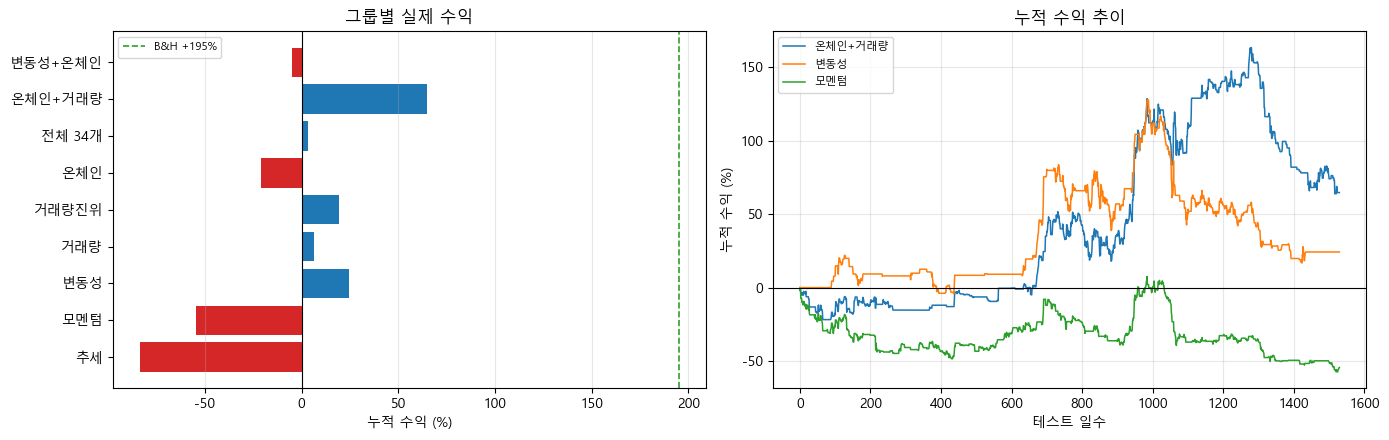

In [85]:
# ===== 셀 3 =====
# Walk-Forward 분할 및 그룹별 비교

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings("ignore")


def make_folds(n, train, test, step, purge):
    folds, start = [], 0
    while start + train + test <= n:
        end = start + train
        folds.append({"train": np.arange(start, end - purge),
                      "test":  np.arange(end, end + test)})
        start += step
    return folds


folds  = make_folds(len(data), TRAIN_DAYS, TEST_DAYS, STEP_DAYS, PURGE_DAYS)
y_all  = data["y"].values
fwd_all = data["fwd_ret"].values

print("=" * 66)
print("검증 구간")
print("=" * 66)
print(f"\n  전체 표본     : {len(data):,}일")
print(f"  폴드 수       : {len(folds)}개")
print(f"  학습 / 테스트 : {len(folds[0]['train'])}일 / {len(folds[0]['test'])}일")
tot = sum(len(f["test"]) for f in folds)
print(f"  총 테스트     : {tot:,}일 ({tot/len(data)*100:.0f}%)")


def run(feats, C=1.0, gamma="scale"):
    """walk-forward 학습 → 예측 확률과 실제 수익률"""
    X = data[feats].values
    P, T, R, FI, IDX = [], [], [], [], []

    for i, f in enumerate(folds):
        tr, te = f["train"], f["test"]
        if len(np.unique(y_all[te])) < 2:
            continue
        sc = StandardScaler().fit(X[tr])
        m = SVC(kernel="rbf", C=C, gamma=gamma,
                probability=True, random_state=42)
        m.fit(sc.transform(X[tr]), y_all[tr])
        P.append(m.predict_proba(sc.transform(X[te]))[:, 1])
        T.append(y_all[te]); R.append(fwd_all[te])
        FI.append(np.full(len(te), i)); IDX.append(te)

    return (np.concatenate(P), np.concatenate(T), np.concatenate(R),
            np.concatenate(FI), np.concatenate(IDX))


def judge(P, T, R, FI, mask, cost=COST_ROUND):
    """세 기준으로 판정"""
    ok  = ~np.isnan(R) & mask
    sig = (P > 0.5) & ok
    n = int(sig.sum())
    if n < 20:
        return None

    tr  = R[sig] - cost
    cum = float(np.exp(tr.sum()) - 1)
    ex3 = float(np.exp(np.sort(tr)[:-3].sum()) - 1) if n > 3 else np.nan
    wr  = float((tr > 0).mean())

    fp = []
    for i in np.unique(FI):
        m = (FI == i) & sig
        if m.sum():
            fp.append(np.exp((R[m] - cost).sum()) - 1 > 0)
    pr = np.mean(fp) if fp else 0

    w = tr[tr > 0].mean() if (tr > 0).any() else 0
    l = -tr[tr < 0].mean() if (tr < 0).any() else 0

    return {"n": n, "wr": wr, "cum": cum, "ex3": ex3, "pos_ratio": pr,
            "auc": roc_auc_score(T[ok], P[ok]),
            "pl": w/l if l > 0 else np.nan,
            "pass": (wr > BREAKEVEN) and (ex3 > 0) and (pr >= 0.5)}


# ── 그룹별 ──────────────────────────────────────────────
print("\n" + "=" * 78)
print(f"그룹별 성능 (손익분기 {BREAKEVEN*100:.2f}%, "
      f"B&H {BH['cum']*100:+.1f}%)")
print("=" * 78)
print(f"\n  {'그룹':12s} {'개수':>4s} {'AUC':>7s} {'거래':>5s} {'승률':>7s} "
      f"{'손익비':>7s} {'누적':>9s} {'구간+':>6s}")
print(f"  {'-'*66}")

group_res = {}
for g, feats in GROUPS.items():
    P, T, R, FI, IDX = run(feats)
    r = judge(P, T, R, FI, np.ones(len(FI), bool))
    if r is None:
        continue
    group_res[g] = r
    mark = "◀" if r["cum"] > 0 else ""
    print(f"  {g:12s} {len(feats):4d} {r['auc']:7.3f} {r['n']:5d} "
          f"{r['wr']*100:6.2f}% {r['pl']:7.2f} {r['cum']*100:+8.1f}% "
          f"{r['pos_ratio']*100:5.0f}% {mark}")

# 전체 + 상위 조합
COMBOS = {"전체 34개": ALL_F,
          "온체인+거래량": ONCHAIN + VOLUME,
          "변동성+온체인": VOLATILITY + ONCHAIN}

print(f"  {'-'*66}")
for name, feats in COMBOS.items():
    P, T, R, FI, IDX = run(feats)
    r = judge(P, T, R, FI, np.ones(len(FI), bool))
    if r is None:
        continue
    group_res[name] = r
    mark = "◀" if r["cum"] > 0 else ""
    print(f"  {name:12s} {len(feats):4d} {r['auc']:7.3f} {r['n']:5d} "
          f"{r['wr']*100:6.2f}% {r['pl']:7.2f} {r['cum']*100:+8.1f}% "
          f"{r['pos_ratio']*100:5.0f}% {mark}")

print(f"\n  {'Buy & Hold':12s} {'':4s} {'—':>7s} {'0':>5s} {'—':>7s} "
      f"{'—':>7s} {BH['cum']*100:+8.1f}%")

# ── 정리 ────────────────────────────────────────────────
print("\n" + "=" * 78)
best_g = max(group_res, key=lambda k: group_res[k]["cum"])
print(f"  최고 : {best_g}  {group_res[best_g]['cum']*100:+.1f}%")
print(f"  손익분기 넘은 조합 : "
      f"{sum(1 for r in group_res.values() if r['wr'] > BREAKEVEN)}개 "
      f"/ {len(group_res)}개")
print(f"  B&H 넘은 조합      : "
      f"{sum(1 for r in group_res.values() if r['cum'] > BH['cum'])}개 "
      f"/ {len(group_res)}개")

# ── 그래프 ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

names = list(group_res.keys())
cums  = [group_res[g]["cum"]*100 for g in names]
axes[0].barh(names, cums,
             color=["tab:blue" if x > 0 else "tab:red" for x in cums])
axes[0].axvline(0, color="black", lw=0.8)
axes[0].axvline(BH["cum"]*100, color="tab:green", ls="--", lw=1.2,
                label=f"B&H {BH['cum']*100:+.0f}%")
axes[0].set_xlabel("누적 수익 (%)")
axes[0].set_title("그룹별 실제 수익")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3, axis="x")

for g in ["온체인+거래량", "변동성", "모멘텀"]:
    if g not in group_res:
        continue
    feats = GROUPS.get(g, COMBOS.get(g))
    P, T, R, FI, IDX = run(feats)
    ok = ~np.isnan(R)
    s = np.where((P > 0.5) & ok, R - COST_ROUND, 0.0)
    axes[1].plot(np.exp(np.nancumsum(s[ok]))*100 - 100, lw=1.1, label=g)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xlabel("테스트 일수")
axes[1].set_ylabel("누적 수익 (%)")
axes[1].set_title("누적 수익 추이")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 그룹별 결과

| 그룹 | AUC | 거래 | 승률 | 손익비 | 누적 |
|---|---|---|---|---|---|
| **온체인+거래량** | 0.510 | 741 | 47.50% | 1.21 | **+64.7%** |
| 변동성 | 0.506 | 585 | 47.18% | 1.18 | +24.3% |
| 거래량진위 | 0.494 | 689 | 46.01% | 1.21 | +19.1% |
| 거래량 | 0.509 | 608 | 47.70% | 1.11 | +6.3% |
| 전체 34개 | 0.488 | 652 | 46.01% | 1.18 | +3.4% |
| 온체인 | 0.499 | 653 | 47.32% | 1.06 | -20.9% |
| 모멘텀 | 0.480 | 844 | 43.96% | 1.12 | -54.5% |
| 추세 | 0.471 | 674 | 43.03% | 0.93 | -83.8% |
| Buy & Hold | — | 0 | — | — | +195.2% |

**따로 쓰면 안 되는 두 그룹이 합치니 살아났습니다.** 온체인 단독은 -20.9%,
거래량 단독은 +6.3%인데 합치면 +64.7%입니다. 온체인은 네트워크 상태를,
거래량은 시장 참여를 보므로 서로 다른 정보를 주는 것으로 보입니다.

**지표를 늘릴수록 나빠졌습니다.** 11개를 쓴 조합이 +64.7%인데 34개 전체를
넣으면 +3.4%입니다. 표본 1,959개에 피처 34개는 과적합을 일으킵니다.

**널리 쓰이는 지표가 최하위**였습니다. MACD와 ADX의 추세 그룹이 -83.8%,
RSI와 스토캐스틱의 모멘텀 그룹이 -54.5%로 바닥이었습니다. 상관 분석에서도
꼴찌였는데 실제 수익에서도 같았습니다.

### 아직 부족합니다

최고 승률이 47.50%로 손익분기(51.43%)에 못 미칩니다. 그리고 어느 조합도
Buy & Hold(+195.2%)를 넘지 못했습니다.

**매일 신호가 나오는 대로 거래했기 때문**입니다. 741회 거래면 5년간 거의 이틀에
한 번꼴인데, 그중 상당수는 확신 없는 진입이었을 것입니다.

**언제 거래할지를 정하는 것**이 다음 과제입니다.

## 4. 모델 비교 — 왜 SVC인가

앞 셀에서 SVC를 썼는데, 왜 그것인지 확인합니다. 다른 모델도 같은 조건에서
돌려봅니다.

| 모델 | 나누는 방식 |
|---|---|
| 로지스틱 회귀 | 직선 하나로 나눔 |
| 랜덤포레스트 | "이 값보다 크냐 작냐"를 반복 |
| LightGBM | 위와 같지만 순차적으로 보완 |
| **SVC (RBF)** | 비슷한 것끼리 뭉친 덩어리를 찾음 |
| LSTM | 시간 순서를 학습 |
| 베이지안 신경망 | 예측과 함께 확신도를 냄 |

### 딥러닝도 넣는 이유

"얕은 모델만 써서 안 된 것 아니냐"는 의문이 생길 수 있습니다. LSTM은 시계열
순서를 학습하고, 베이지안 신경망은 예측 불확실성까지 냅니다.

**베이지안 신경망은 특히 흥미롭습니다.** 같은 입력에 대해 여러 번 예측해서
평균과 분산을 구합니다. 분산이 작으면 모델이 확신한다는 뜻이니, **확신 있는
날만 거래**하면 나아질 수 있습니다.

### 다만 표본이 적습니다

1,959일에 파라미터가 수천 개인 신경망을 쓰면 과적합 위험이 큽니다.

모델 비교 (온체인+거래량 11개, 손익분기 51.43%)

  모델                 AUC    거래      승률     손익비        누적    구간+
  ----------------------------------------------------------
  로지스틱             0.472   827  42.81%    1.11    -69.7%    29% 
  랜덤포레스트           0.497   736  45.38%    1.03    -58.2%    35% 
  LightGBM         0.477   749  44.86%    0.99    -71.5%    29% 
  SVC(RBF)         0.510   741  47.50%    1.21    +64.7%    50% ◀
  LSTM             0.481   780  44.23%    1.09    -54.8%    35%
  베이지안NN           0.465   822  44.28%    0.97    -78.9%    29%

베이지안 신경망 — 확신할수록 잘 맞히는가

  예측 분산 구간                   개수      정확도
  ----------------------------------------
  0.0115 ~ 0.1258 확신 높음       383   45.69%
  0.1258 ~ 0.1606             382   49.74%
  0.1606 ~ 0.2007             382   50.79%
  0.2007 ~ 0.4126 확신 낮음       383   47.00%

  → 확신 높은 쪽 45.69% vs 낮은 쪽 47.00%
     역전 (확신할수록 더 틀림)

  최고 : SVC(RBF)  +64.7%
  얕은 모델 최고 : SVC(RBF) +64.7%
  딥러닝 최고    : LSTM -54.8%


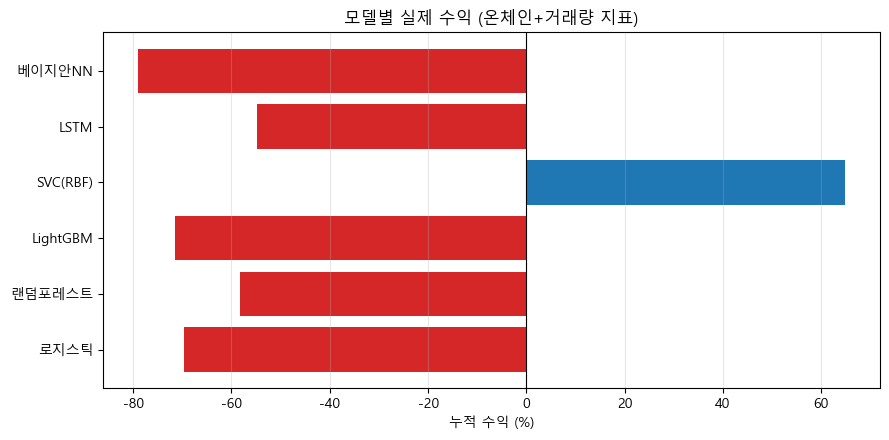

In [86]:
# ===== 셀 4 =====
# 모델 비교

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

try:
    import torch, torch.nn as nn
    torch.manual_seed(42)
    TORCH_OK = True
except ImportError:
    TORCH_OK = False
    print("torch 미설치 → pip install torch")

FEATS = ONCHAIN + VOLUME          # 앞 셀에서 가장 나았던 조합
X_f = data[FEATS].values
n_feat = len(FEATS)

# ── 얕은 모델 ───────────────────────────────────────────
SHALLOW = {
    "로지스틱":  ("scale", lambda: LogisticRegression(max_iter=1000, C=0.5)),
    "랜덤포레스트": ("raw", lambda: RandomForestClassifier(
        n_estimators=200, max_depth=4, min_samples_leaf=30,
        random_state=42, n_jobs=-1)),
    "LightGBM": ("raw", lambda: lgb.LGBMClassifier(
        objective="binary", learning_rate=0.05, num_leaves=7, max_depth=3,
        min_child_samples=50, n_estimators=100, verbose=-1, random_state=42)),
    "SVC(RBF)": ("scale", lambda: SVC(kernel="rbf", C=1.0, gamma="scale",
                                      probability=True, random_state=42)),
}

def run_model(mode, maker):
    P, T, R, FI = [], [], [], []
    for i, f in enumerate(folds):
        tr, te = f["train"], f["test"]
        if len(np.unique(y_all[te])) < 2:
            continue
        if mode == "scale":
            sc = StandardScaler().fit(X_f[tr])
            a, b = sc.transform(X_f[tr]), sc.transform(X_f[te])
        else:
            a, b = X_f[tr], X_f[te]
        m = maker()
        m.fit(a, y_all[tr])
        P.append(m.predict_proba(b)[:, 1])
        T.append(y_all[te]); R.append(fwd_all[te])
        FI.append(np.full(len(te), i))
    return (np.concatenate(P), np.concatenate(T),
            np.concatenate(R), np.concatenate(FI))


print("=" * 74)
print(f"모델 비교 (온체인+거래량 11개, 손익분기 {BREAKEVEN*100:.2f}%)")
print("=" * 74)
print(f"\n  {'모델':14s} {'AUC':>7s} {'거래':>5s} {'승률':>7s} "
      f"{'손익비':>7s} {'누적':>9s} {'구간+':>6s}")
print(f"  {'-'*58}")

model_res = {}
for name, (mode, mk) in SHALLOW.items():
    P, T, R, FI = run_model(mode, mk)
    r = judge(P, T, R, FI, np.ones(len(FI), bool))
    model_res[name] = r
    mark = "◀" if r["cum"] > 0 else ""
    print(f"  {name:14s} {r['auc']:7.3f} {r['n']:5d} {r['wr']*100:6.2f}% "
          f"{r['pl']:7.2f} {r['cum']*100:+8.1f}% "
          f"{r['pos_ratio']*100:5.0f}% {mark}")

# ── 딥러닝 ──────────────────────────────────────────────
if TORCH_OK:
    SEQ = 20

    class LSTMNet(nn.Module):
        def __init__(self, nf, hid=16):
            super().__init__()
            self.lstm = nn.LSTM(nf, hid, batch_first=True)
            self.drop = nn.Dropout(0.2)
            self.fc = nn.Linear(hid, 1)
        def forward(self, x):
            o, _ = self.lstm(x)
            return torch.sigmoid(self.fc(self.drop(o[:, -1, :]))).squeeze(-1)

    class BayesNet(nn.Module):
        """드롭아웃을 예측할 때도 켜서 여러 번 뽑음 → 분산이 확신도"""
        def __init__(self, nf, hid=32, p=0.3):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(nf, hid), nn.ReLU(), nn.Dropout(p),
                nn.Linear(hid, hid//2), nn.ReLU(), nn.Dropout(p),
                nn.Linear(hid//2, 1))
        def forward(self, x):
            return torch.sigmoid(self.net(x)).squeeze(-1)
        def dist(self, x, n=50):
            self.train()
            with torch.no_grad():
                ps = torch.stack([self(x) for _ in range(n)])
            return ps.mean(0).numpy(), ps.std(0).numpy()

    def train_nn(model, Xtr, ytr, epochs=100, lr=0.01):
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        lf = nn.BCELoss()
        Xt = torch.tensor(Xtr, dtype=torch.float32)
        yt = torch.tensor(ytr, dtype=torch.float32)
        model.train()
        for _ in range(epochs):
            opt.zero_grad(); lf(model(Xt), yt).backward(); opt.step()
        return model

    # LSTM
    P, T, R, FI = [], [], [], []
    for i, f in enumerate(folds):
        tr, te = f["train"], f["test"]
        sc = StandardScaler().fit(X_f[tr]); Xs = sc.transform(X_f)
        xtr = np.array([Xs[j-SEQ:j] for j in tr if j >= SEQ], dtype=np.float32)
        ytr = np.array([y_all[j] for j in tr if j >= SEQ], dtype=np.float32)
        tev = [j for j in te if j >= SEQ]
        xte = np.array([Xs[j-SEQ:j] for j in tev], dtype=np.float32)
        if len(xtr) < 100 or len(xte) < 20:
            continue
        if len(np.unique(y_all[tev])) < 2:
            continue
        m = train_nn(LSTMNet(n_feat), xtr, ytr, epochs=50)
        m.eval()
        with torch.no_grad():
            P.append(m(torch.tensor(xte)).numpy())
        T.append(y_all[tev]); R.append(fwd_all[tev])
        FI.append(np.full(len(tev), i))

    r = judge(np.concatenate(P), np.concatenate(T),
              np.concatenate(R), np.concatenate(FI),
              np.ones(len(np.concatenate(P)), bool))
    model_res["LSTM"] = r
    print(f"  {'LSTM':14s} {r['auc']:7.3f} {r['n']:5d} {r['wr']*100:6.2f}% "
          f"{r['pl']:7.2f} {r['cum']*100:+8.1f}% {r['pos_ratio']*100:5.0f}%")

    # 베이지안 NN
    P, T, R, FI, S = [], [], [], [], []
    for i, f in enumerate(folds):
        tr, te = f["train"], f["test"]
        if len(np.unique(y_all[te])) < 2:
            continue
        sc = StandardScaler().fit(X_f[tr])
        m = train_nn(BayesNet(n_feat),
                     sc.transform(X_f[tr]).astype(np.float32),
                     y_all[tr].astype(np.float32), epochs=200)
        mu, sd = m.dist(torch.tensor(sc.transform(X_f[te]),
                                     dtype=torch.float32))
        P.append(mu); S.append(sd); T.append(y_all[te])
        R.append(fwd_all[te]); FI.append(np.full(len(te), i))

    Pb, Sb = np.concatenate(P), np.concatenate(S)
    Tb, Rb, FIb = np.concatenate(T), np.concatenate(R), np.concatenate(FI)
    r = judge(Pb, Tb, Rb, FIb, np.ones(len(Pb), bool))
    model_res["베이지안NN"] = r
    print(f"  {'베이지안NN':14s} {r['auc']:7.3f} {r['n']:5d} "
          f"{r['wr']*100:6.2f}% {r['pl']:7.2f} {r['cum']*100:+8.1f}% "
          f"{r['pos_ratio']*100:5.0f}%")

    # ── 확신도가 실제로 맞는가 ──────────────────────────
    print("\n" + "=" * 74)
    print("베이지안 신경망 — 확신할수록 잘 맞히는가")
    print("=" * 74)
    print(f"\n  {'예측 분산 구간':22s} {'개수':>6s} {'정확도':>8s}")
    print(f"  {'-'*40}")
    qs = np.quantile(Sb, [0, 0.25, 0.5, 0.75, 1.0])
    accs = []
    for i in range(4):
        m = (Sb >= qs[i]) & (Sb < qs[i+1] + 1e-12)
        if m.sum() < 20:
            continue
        acc = ((Pb[m] > 0.5).astype(int) == Tb[m]).mean()
        accs.append(acc)
        lab = "확신 높음" if i == 0 else ("확신 낮음" if i == 3 else "")
        print(f"  {qs[i]:.4f} ~ {qs[i+1]:.4f} {lab:8s} "
              f"{m.sum():6d} {acc*100:7.2f}%")

    if len(accs) == 4:
        print(f"\n  → 확신 높은 쪽 {accs[0]*100:.2f}% vs "
              f"낮은 쪽 {accs[3]*100:.2f}%")
        print(f"     {'정상 (확신할수록 잘 맞힘)' if accs[0] > accs[3] else '역전 (확신할수록 더 틀림)'}")

# ── 정리 ────────────────────────────────────────────────
print("\n" + "=" * 74)
best_m = max(model_res, key=lambda k: model_res[k]["cum"])
print(f"  최고 : {best_m}  {model_res[best_m]['cum']*100:+.1f}%")

shallow_best = max([k for k in model_res if k in SHALLOW],
                   key=lambda k: model_res[k]["cum"])
deep = [k for k in model_res if k not in SHALLOW]
if deep:
    deep_best = max(deep, key=lambda k: model_res[k]["cum"])
    print(f"  얕은 모델 최고 : {shallow_best} "
          f"{model_res[shallow_best]['cum']*100:+.1f}%")
    print(f"  딥러닝 최고    : {deep_best} "
          f"{model_res[deep_best]['cum']*100:+.1f}%")

# ── 그래프 ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))
names = list(model_res.keys())
cums  = [model_res[k]["cum"]*100 for k in names]
ax.barh(names, cums,
        color=["tab:blue" if x > 0 else "tab:red" for x in cums])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("누적 수익 (%)")
ax.set_title("모델별 실제 수익 (온체인+거래량 지표)")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

### 모델 비교 결과

| 모델 | AUC | 승률 | 손익비 | 누적 | 구간+ |
|---|---|---|---|---|---|
| **SVC(RBF)** | 0.510 | 47.50% | **1.21** | **+64.7%** | 50% |
| LSTM | 0.481 | 44.23% | 1.09 | -54.8% | 35% |
| 랜덤포레스트 | 0.497 | 45.38% | 1.03 | -58.2% | 35% |
| 로지스틱 | 0.472 | 42.81% | 1.11 | -69.7% | 29% |
| LightGBM | 0.477 | 44.86% | 0.99 | -71.5% | 29% |
| 베이지안NN | 0.465 | 44.28% | 0.97 | -78.9% | 29% |

**여섯 중 SVC만 플러스였습니다.** 승률이 47.50%로 가장 높고, 손익비도 1.21로
유일하게 뚜렷하게 1을 넘습니다. 즉 **더 자주 맞히고 이길 때 더 크게 법니다.**

RBF 커널은 비슷한 상태끼리 뭉친 덩어리를 찾는 방식입니다. 큰 움직임이 나오는
시장 국면을 잡아낸 것으로 보입니다.

**딥러닝은 확실히 안 됐습니다.** LSTM -54.8%, 베이지안 신경망 -78.9%로
얕은 모델보다도 나빴습니다. 표본 1,959일에 파라미터가 수천 개인 신경망을 쓰니
과적합이 일어난 것으로 보입니다.

### 확신도가 반대로 작동했습니다

베이지안 신경망은 같은 입력에 여러 번 예측해서 분산을 냅니다. 분산이 작으면
모델이 확신한다는 뜻이죠. 그런데 결과가 예상과 반대였습니다.

| 예측 분산 | 정확도 |
|---|---|
| **가장 작음 (확신 높음)** | **45.69%** |
| 중간 | 50.79% |
| 가장 큼 (확신 낮음) | 47.00% |

**확신할수록 더 틀렸습니다.**

분산이 작다는 것은 학습 데이터의 특정 패턴에 강하게 맞춰졌다는 뜻입니다.
그 패턴이 테스트 구간에서 깨지면 확신한 만큼 크게 틀리게 됩니다.

**따라서 예측 확신도를 거래 필터로 쓸 수 없습니다.** "확신 있는 날만 거래하자"는
접근은 여기서 작동하지 않습니다. 다른 기준이 필요합니다.

## 5. 언제 거래할 것인가

앞 셀에서 SVC가 +64.7%를 냈지만 승률은 47.50%였습니다. 손익분기(51.43%)에
못 미치고 Buy & Hold(+195.2%)에도 한참 모자랍니다.

**741번 거래가 너무 많습니다.** 5년간 이틀에 한 번꼴인데, 그중 상당수는 좋지
않은 상황에서의 진입이었을 겁니다.

### 확신도는 못 씁니다

앞 셀에서 확인했듯 모델의 확신도가 반대로 작동했습니다. 확신할수록 더 틀렸죠.
그래서 **시장 상태로 필터를 만듭니다.**

### 두 가지를 조정합니다

**모델 설정** — SVC의 C와 gamma를 바꿔봅니다. C는 학습 데이터를 얼마나 맞추려
하는지, gamma는 한 점의 영향이 얼마나 멀리 미치는지를 정합니다.

**시장 상태 필터** — 이런 조건들을 조합합니다.

| 조건 | 뜻 |
|---|---|
| MA30 위 | 단기 추세가 위 |
| MA100 위 / MA200 위 | 중장기 추세도 위 |
| 60일 낙폭 -20% 이내 | 최근 고점에서 크게 안 빠짐 |
| MA30 상승 중 | 이동평균 자체가 오르는 중 |

**거래는 줄지만 남은 거래의 질이 오를 수 있습니다.**

### 무엇을 기준으로 고르나

수익만 보면 안 됩니다. 소수의 큰 거래로 만든 수익은 재현되지 않으니까요.
그래서 세 가지를 다 봅니다.

- 승률이 손익분기를 넘는가
- 상위 3건을 빼도 플러스인가
- 17개 구간 중 절반 이상에서 플러스인가

### 조심할 점

여러 조합을 시험해서 잘 나온 걸 고르면 과적합입니다. **결과를 전부 정리**하고,
**다음 셀에서 hold-out으로 검증**하겠습니다.

SVC 설정 조정 (필터 없이)

      C   gamma    거래      승률     손익비        누적
  ----------------------------------------------
    0.5   scale   747  47.12%    1.17    +26.1%
    0.5    0.02   668  46.56%    1.00    -49.9%
    0.5    0.05   679  47.86%    1.16    +36.5%
    1.0   scale   741  47.50%    1.21    +64.7%
    1.0    0.02   712  48.46%    1.03    -13.5%
    1.0    0.05   647  48.84%    1.27   +136.4%
    2.0   scale   664  48.34%    1.18    +63.8%
    2.0    0.02   567  50.62%    1.29   +197.7%
    2.0    0.05   676  48.08%    1.19    +61.5%

  최적 : C=2.0, gamma=0.02  (+197.7%)

필터별 성능 (손익분기 51.43%, B&H +195.2%)

  필터                          거래      승률     손익비        누적    구간+
  --------------------------------------------------------------
  없음                         567  50.62%    1.29   +197.7%    60% 
  MA30 위                     301  52.82%    1.27    +96.6%    57% ◀
  MA30 + 낙폭60                292  53.42%    1.30   +109.6%    57% ◀
  MA30 + MA100               236  53.81%    1

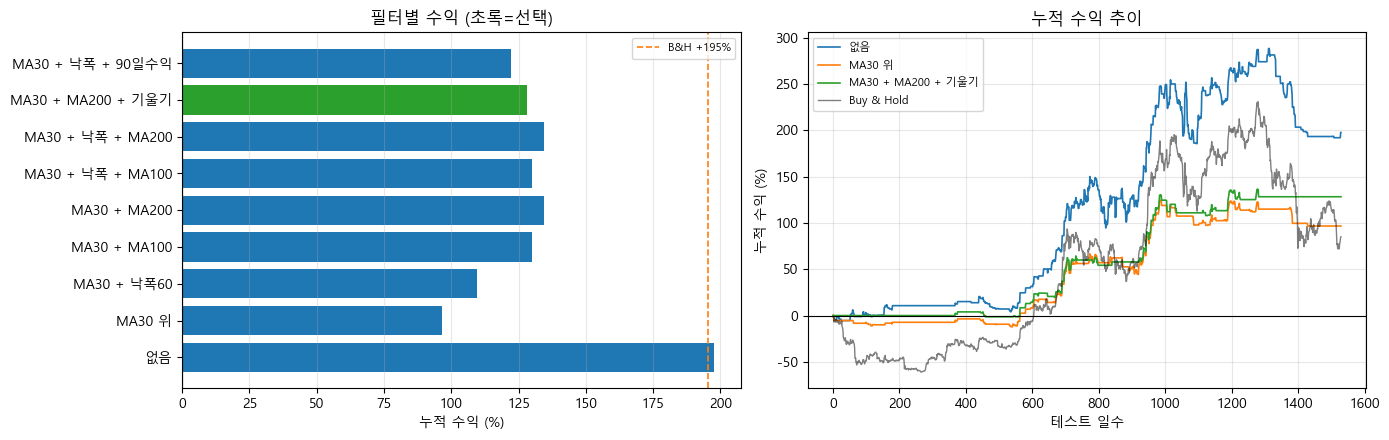

In [88]:
# ===== 셀 5 =====
# 모델 설정 조정 + 시장 상태 필터

FEATS = ONCHAIN + VOLUME
c_all = data["close"]

# ── 시장 상태 지표 (모두 하루 전 정보) ──────────────────
mkt = pd.DataFrame(index=data.index)
mkt["ma30_up"]    = (c_all > c_all.rolling(30).mean()).shift(1).astype(float)
mkt["ma100_up"]   = (c_all > c_all.rolling(100).mean()).shift(1).astype(float)
mkt["ma200_up"]   = (c_all > c_all.rolling(200).mean()).shift(1).astype(float)
mkt["ma30_slope"] = (c_all.rolling(30).mean().diff(10) > 0).shift(1).astype(float)
mkt["dd60"]       = (c_all / c_all.rolling(60).max() - 1).shift(1)
mkt["ret90"]      = np.log(c_all / c_all.shift(90)).shift(1)

# ── 1) SVC 설정 조정 ────────────────────────────────────
print("=" * 76)
print("SVC 설정 조정 (필터 없이)")
print("=" * 76)
print(f"\n  {'C':>5s} {'gamma':>7s} {'거래':>5s} {'승률':>7s} "
      f"{'손익비':>7s} {'누적':>9s}")
print(f"  {'-'*46}")

best_cfg, best_cum = None, -9
for C in [0.5, 1.0, 2.0]:
    for gm in ["scale", 0.02, 0.05]:
        P_, T_, R_, FI_, _ = run(FEATS, C, gm)
        r = judge(P_, T_, R_, FI_, np.ones(len(FI_), bool))
        if r is None:
            continue
        if r["cum"] > best_cum:
            best_cum, best_cfg = r["cum"], (C, gm)
        print(f"  {C:5.1f} {str(gm):>7s} {r['n']:5d} {r['wr']*100:6.2f}% "
              f"{r['pl']:7.2f} {r['cum']*100:+8.1f}%")

C_BEST, G_BEST = best_cfg
print(f"\n  최적 : C={C_BEST}, gamma={G_BEST}  ({best_cum*100:+.1f}%)")

# ── 2) 필터 조합 ────────────────────────────────────────
P, T, R, FI, IDX = run(FEATS, C_BEST, G_BEST)
M = mkt.iloc[IDX]

FILTERS = {
    "없음":
        np.ones(len(IDX), bool),
    "MA30 위":
        (M["ma30_up"] > 0).values,
    "MA30 + 낙폭60":
        ((M["ma30_up"] > 0) & (M["dd60"] > -0.20)).values,
    "MA30 + MA100":
        ((M["ma30_up"] > 0) & (M["ma100_up"] > 0)).values,
    "MA30 + MA200":
        ((M["ma30_up"] > 0) & (M["ma200_up"] > 0)).values,
    "MA30 + 낙폭 + MA100":
        ((M["ma30_up"] > 0) & (M["dd60"] > -0.20) &
         (M["ma100_up"] > 0)).values,
    "MA30 + 낙폭 + MA200":
        ((M["ma30_up"] > 0) & (M["dd60"] > -0.20) &
         (M["ma200_up"] > 0)).values,
    "MA30 + MA200 + 기울기":
        ((M["ma30_up"] > 0) & (M["ma200_up"] > 0) &
         (M["ma30_slope"] > 0)).values,
    "MA30 + 낙폭 + 90일수익":
        ((M["ma30_up"] > 0) & (M["dd60"] > -0.20) &
         (M["ret90"] > 0)).values,
}

print("\n" + "=" * 76)
print(f"필터별 성능 (손익분기 {BREAKEVEN*100:.2f}%, "
      f"B&H {BH['cum']*100:+.1f}%)")
print("=" * 76)
print(f"\n  {'필터':24s} {'거래':>5s} {'승률':>7s} {'손익비':>7s} "
      f"{'누적':>9s} {'구간+':>6s}")
print(f"  {'-'*62}")

filt_res = {}
for fname, fmask in FILTERS.items():
    r = judge(P, T, R, FI, fmask)
    if r is None:
        print(f"  {fname:24s} 표본 부족")
        continue
    filt_res[fname] = {"r": r, "mask": fmask}
    mark = "◀" if r["pass"] else ("△" if r["wr"] > BREAKEVEN else "")
    print(f"  {fname:24s} {r['n']:5d} {r['wr']*100:6.2f}% {r['pl']:7.2f} "
          f"{r['cum']*100:+8.1f}% {r['pos_ratio']*100:5.0f}% {mark}")

print(f"\n  ◀ 세 기준 통과   △ 승률만 통과")

# ── 3) 최종 필터 선정 ───────────────────────────────────
# 수익이 아니라 '세 기준 통과 + 손익비'로 고른다
passed = {k: v for k, v in filt_res.items()
          if v["r"]["pass"] and k != "없음"}

if passed:
    best_f = max(passed, key=lambda k: passed[k]["r"]["pl"])
else:
    best_f = max(filt_res, key=lambda k: filt_res[k]["r"]["cum"])

base = filt_res["없음"]["r"]
bf   = filt_res[best_f]

print("\n" + "=" * 76)
print("필터 효과 — 무엇이 달라졌나")
print("=" * 76)
print(f"\n  {'':16s} {'필터 없음':>12s} {best_f[:16]:>16s}")
print(f"  {'-'*46}")
print(f"  {'거래 수':16s} {base['n']:12d} {bf['r']['n']:16d}")
print(f"  {'승률':16s} {base['wr']*100:11.2f}% {bf['r']['wr']*100:15.2f}%")
print(f"  {'손익분기 대비':16s} {(base['wr']-BREAKEVEN)*100:+11.2f}%p "
      f"{(bf['r']['wr']-BREAKEVEN)*100:+14.2f}%p")
print(f"  {'손익비':16s} {base['pl']:12.2f} {bf['r']['pl']:16.2f}")
print(f"  {'누적 수익':16s} {base['cum']*100:+11.1f}% "
      f"{bf['r']['cum']*100:+15.1f}%")
print(f"  {'구간+ 비율':16s} {base['pos_ratio']*100:11.0f}% "
      f"{bf['r']['pos_ratio']*100:15.0f}%")

# ── 4) 큰 움직임을 어떻게 걸렀나 ────────────────────────
ok_b  = ~np.isnan(R)
sig_b = (P > 0.5) & ok_b
ok_f  = ~np.isnan(R) & bf["mask"]
sig_f = (P > 0.5) & ok_f

print(f"\n  큰 움직임 포착")
for lab, cond in [("+3% 이상 상승", R > 0.03), ("-3% 이상 하락", R < -0.03)]:
    nb, sb = (cond & ok_b).sum(), (cond & sig_b).sum()
    nf, sf = (cond & ok_f).sum(), (cond & sig_f).sum()
    print(f"    {lab}")
    print(f"      필터없음 : {sb:3d}/{nb:3d}회 진입 "
          f"({sb/max(nb,1)*100:.0f}%)")
    print(f"      필터적용 : {sf:3d}/{nf:3d}회 진입 "
          f"({sf/max(nf,1)*100:.0f}%)")

BEST_FILTER      = bf["mask"]
BEST_FILTER_NAME = best_f
print(f"\n  → 다음 셀에서 '{best_f}'를 검증합니다")

# ── 그래프 ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

names = list(filt_res.keys())
cums  = [filt_res[k]["r"]["cum"]*100 for k in names]
cols  = ["tab:green" if k == best_f else
         ("tab:blue" if x > 0 else "tab:red")
         for k, x in zip(names, cums)]
axes[0].barh(names, cums, color=cols)
axes[0].axvline(0, color="black", lw=0.8)
axes[0].axvline(BH["cum"]*100, color="tab:orange", ls="--", lw=1.2,
                label=f"B&H {BH['cum']*100:+.0f}%")
axes[0].set_xlabel("누적 수익 (%)")
axes[0].set_title("필터별 수익 (초록=선택)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3, axis="x")

okR = ~np.isnan(R)
for k in ["없음", "MA30 위", best_f]:
    if k not in filt_res:
        continue
    s = np.where((P > 0.5) & okR & filt_res[k]["mask"], R - COST_ROUND, 0.0)
    axes[1].plot(np.exp(np.nancumsum(s[okR]))*100 - 100, lw=1.2, label=k)
axes[1].plot(np.exp(np.nancumsum(R[okR]))*100 - 100, lw=1,
             color="black", alpha=0.5, label="Buy & Hold")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xlabel("테스트 일수")
axes[1].set_ylabel("누적 수익 (%)")
axes[1].set_title("누적 수익 추이")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 설정 조정 결과

SVC의 C=2.0, gamma=0.02가 가장 나았습니다(+197.7%). 다만 **승률이 50.62%로
손익분기(51.43%)에 미달**했습니다. 소수의 큰 거래로 만든 수익이라는 뜻입니다.

### 필터 효과

| | 필터 없음 | MA30+MA200+기울기 |
|---|---|---|
| 거래 수 | 567 | **189** |
| 승률 | 50.62% | **54.50%** |
| 손익분기 대비 | -0.81%p | **+3.07%p** |
| 손익비 | 1.29 | **1.61** |
| 누적 수익 | +197.7% | +128.2% |
| 구간+ 비율 | 60% | **73%** |

**거래를 3분의 1로 줄이면서 승률이 3.9%p 올랐고, 손익분기를 넘겼습니다.**
수익은 줄었지만 거래가 발생한 구간 중 73%에서 플러스라 훨씬 안정적입니다.

### 필터가 한 일

예상과 달랐습니다. 필터가 위험한 날을 골라낸 것이 아니라 **위험한 구간을
통째로 제외**했습니다.

| | 필터 없음 | 필터 적용 |
|---|---|---|
| -3% 이상 하락일 | 90회 중 23회 진입 (26%) | 22회 중 5회 진입 (23%) |

진입 비율은 거의 같은데 **하락일 자체가 90회에서 22회로 줄었습니다.**
MA200 위이고 MA30이 상승 중이면 이미 안정적인 구간이라 큰 하락이 드뭅니다.

### 낙폭 조건은 필요 없었습니다

```
MA30 + MA100          236회   +129.8%
MA30 + 낙폭 + MA100   236회   +129.8%   (완전히 동일)
```


60일 낙폭 -20% 이내 조건이 아무것도 걸러내지 못했습니다. MA100 위면 이미
큰 낙폭이 아니기 때문입니다. **조건을 하나 줄일 수 있다는 뜻이고, 단순할수록
과적합 위험이 낮으므로 좋은 결과입니다.**

### 다음

여러 조합을 시험해서 고른 것이므로 우연일 수 있습니다. 다음 셀에서 앞뒤로
나눠 검증하겠습니다.

## 6. 검증 — 우연이 아닌가

앞 셀에서 조건을 여럿 시험해서 하나를 골랐습니다. **그러면 우연히 좋게 나온
것을 고른 것일 수 있습니다.**

여러 번 시도하면 그중 하나는 좋게 나오기 마련입니다. 그래서 네 가지로
확인합니다.

### 1. 앞뒤로 나눠서

폴드 17개를 앞 8개와 뒤 9개로 나눕니다. **앞에서 통한 조건이 뒤에서도 통하면**
재현성이 있는 겁니다.

이건 학습에 쓰지 않은 구간으로 확인하는 방식입니다.

### 2. 셋으로 나눠서

시기를 셋으로 갈라 각각에서 어떤지 봅니다. **특정 시기에만 몰려 있으면**
그 시기 특성일 뿐입니다.

### 3. 무작위와 비교

같은 필터 구간에서 **아무 날이나 골라 거래**했다면 어땠을지 2,000번
시뮬레이션합니다.

이게 중요합니다. 필터만으로도 성과가 날 수 있는데, **모델이 그 위에 얼마나
더했는지**를 봐야 하니까요.

실제 성과가 무작위 상위 5% 안에 들면 모델이 실제로 기여한 겁니다.

### 4. 비용을 얼마까지 견디는가

수수료와 슬리피지를 바꿔가며 어디서 무너지는지 확인합니다. **성립하는 비용
상한을 특정**하는 것이 목적입니다.

검증 대상 : MA30 + MA200 + 기울기  (C=2.0, gamma=0.02)

1. 앞뒤 검증

  구간            거래      승률     손익비        누적      상위3제외    구간+
  ------------------------------------------------------------
  전체           189  54.50%    1.61   +128.2%     +78.0%    73% ◀
  앞 절반          58  55.17%    2.26    +59.6%     +27.1%    75% ◀
  뒤 절반         131  54.20%    1.33    +43.0%     +22.7%    71% ◀

  승률 차이 : 0.97%p (재현됨)

2. 시기 3분할

  구간                             기간    거래      승률     손익비        누적
  ----------------------------------------------------------------
  1구간      표본 부족
  2구간      2023-07-01~2024-12-21   130  56.92%    1.82   +118.0% ◀
  3구간      2024-12-22~2026-06-14    54  50.00%    1.05     +1.7% ◀

      연도    거래      승률        수익
  --------------------------------
    2023    32  46.88%    +24.2%
    2024   104  59.62%    +80.7%
    2025    53  49.06%     +1.6%

  플러스 연도 : 3개 / 3개

3. 무작위 대조 — 같은 구간에서 아무 날이나 거래했다면

  실제 전략   : +128.2%  (189회 거래)
  무작위 평균 : +29.5%
  무작위 5~95%: -12.8% ~ +86.

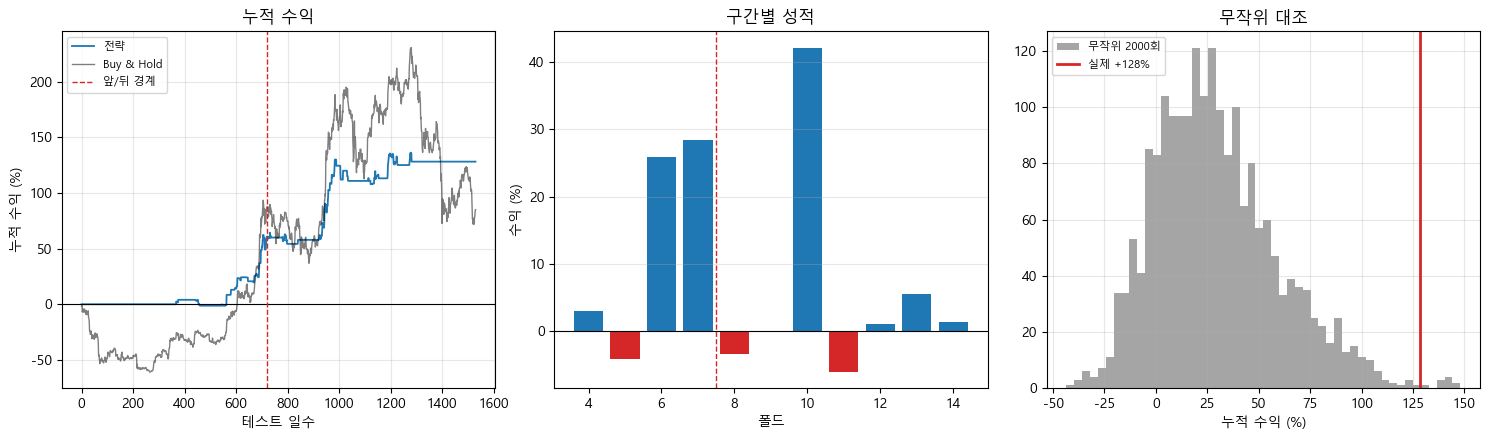

In [89]:
# ===== 셀 6 =====
# 검증: hold-out, 3분할, 무작위 대조, 비용 민감도

P, T, R, FI, IDX = run(FEATS, C_BEST, G_BEST)
FM = BEST_FILTER

HALF = len(folds) // 2
T1, T2 = len(folds) // 3, (len(folds) * 2) // 3

print("=" * 76)
print(f"검증 대상 : {BEST_FILTER_NAME}  (C={C_BEST}, gamma={G_BEST})")
print("=" * 76)

# ── 1. 앞뒤 나누기 ──────────────────────────────────────
print("\n" + "=" * 76)
print("1. 앞뒤 검증")
print("=" * 76)
print(f"\n  {'구간':10s} {'거래':>5s} {'승률':>7s} {'손익비':>7s} "
      f"{'누적':>9s} {'상위3제외':>10s} {'구간+':>6s}")
print(f"  {'-'*60}")

for lab, hm in [("전체", np.ones(len(FI), bool)),
                ("앞 절반", FI < HALF), ("뒤 절반", FI >= HALF)]:
    r = judge(P, T, R, FI, FM & hm)
    if r is None:
        continue
    mark = "◀" if r["pass"] else ""
    print(f"  {lab:10s} {r['n']:5d} {r['wr']*100:6.2f}% {r['pl']:7.2f} "
          f"{r['cum']*100:+8.1f}% {r['ex3']*100:+9.1f}% "
          f"{r['pos_ratio']*100:5.0f}% {mark}")

r_in  = judge(P, T, R, FI, FM & (FI < HALF))
r_out = judge(P, T, R, FI, FM & (FI >= HALF))
if r_in and r_out:
    print(f"\n  승률 차이 : {abs(r_in['wr']-r_out['wr'])*100:.2f}%p "
          f"({'재현됨' if abs(r_in['wr']-r_out['wr']) < 0.03 else '차이 큼'})")

# ── 2. 3분할 ────────────────────────────────────────────
print("\n" + "=" * 76)
print("2. 시기 3분할")
print("=" * 76)
print(f"\n  {'구간':8s} {'기간':>24s} {'거래':>5s} {'승률':>7s} "
      f"{'손익비':>7s} {'누적':>9s}")
print(f"  {'-'*64}")

for lab, a, b in [("1구간", 0, T1), ("2구간", T1, T2),
                  ("3구간", T2, len(folds))]:
    sm = (FI >= a) & (FI < b)
    r = judge(P, T, R, FI, FM & sm)
    if r is None:
        print(f"  {lab:8s} 표본 부족")
        continue
    ix = IDX[sm]
    d0, d1 = data.index[ix[0]], data.index[ix[-1]]
    mark = "◀" if r["cum"] > 0 else ""
    print(f"  {lab:8s} {d0:%Y-%m-%d}~{d1:%Y-%m-%d} {r['n']:5d} "
          f"{r['wr']*100:6.2f}% {r['pl']:7.2f} {r['cum']*100:+8.1f}% {mark}")

# 연도별
ok  = ~np.isnan(R) & FM
sig = (P > 0.5) & ok
yrs = pd.Series(data.index[IDX[sig]]).dt.year
tr_all = R[sig] - COST_ROUND

print(f"\n  {'연도':>6s} {'거래':>5s} {'승률':>7s} {'수익':>9s}")
print(f"  {'-'*32}")
yg = pd.DataFrame({"year": yrs.values, "ret": tr_all}).groupby("year")
n_pos_y = 0
for y, g in yg:
    cy = np.exp(g["ret"].sum()) - 1
    n_pos_y += cy > 0
    print(f"  {int(y):6d} {len(g):5d} {(g['ret']>0).mean()*100:6.2f}% "
          f"{cy*100:+8.1f}%")
print(f"\n  플러스 연도 : {n_pos_y}개 / {len(yg)}개")

# ── 3. 무작위 대조 ──────────────────────────────────────
print("\n" + "=" * 76)
print("3. 무작위 대조 — 같은 구간에서 아무 날이나 거래했다면")
print("=" * 76)

n_act  = int(sig.sum())
actual = float(np.exp(tr_all.sum()) - 1)

rng = np.random.default_rng(42)
pool = np.where(ok)[0]
sims = np.array([
    np.exp((R[rng.choice(pool, min(n_act, len(pool)), replace=False)]
            - COST_ROUND).sum()) - 1
    for _ in range(2000)])

pct = (sims < actual).mean()

print(f"\n  실제 전략   : {actual*100:+.1f}%  ({n_act}회 거래)")
print(f"  무작위 평균 : {sims.mean()*100:+.1f}%")
print(f"  무작위 5~95%: {np.percentile(sims,5)*100:+.1f}% ~ "
      f"{np.percentile(sims,95)*100:+.1f}%")
print(f"\n  실제가 무작위 상위 {(1-pct)*100:.1f}%")
print(f"  → {'모델이 기여함' if pct > 0.95 else '모델 기여 불확실'}")

# ── 4. 비용 민감도 ──────────────────────────────────────
print("\n" + "=" * 76)
print("4. 비용을 얼마까지 견디는가")
print("=" * 76)
print(f"\n  {'왕복 비용':16s} {'승률':>7s} {'손익비':>7s} {'누적':>9s} "
      f"{'구간+':>6s} {'판정':>6s}")
print(f"  {'-'*56}")

COSTS = {"0.00% (비용 없음)": 0.0,
         "0.05%": 0.0005,
         "0.10% (수수료만)": 0.0010,
         "0.15%": 0.0015,
         "0.20% (수수료+슬리피지)": 0.0020,
         "0.30%": 0.0030}

max_cost = 0
for clab, cst in COSTS.items():
    r = judge(P, T, R, FI, FM, cst)
    if r is None:
        continue
    if r["pass"]:
        max_cost = max(max_cost, cst)
    mark = "◀" if r["pass"] else ""
    print(f"  {clab:16s} {r['wr']*100:6.2f}% {r['pl']:7.2f} "
          f"{r['cum']*100:+8.1f}% {r['pos_ratio']*100:5.0f}% {mark:>6s}")

print(f"\n  성립하는 최대 비용 : {max_cost*100:.2f}%")
print(f"  업비트 수수료 왕복 : 0.10%")
print(f"  → {'실현 가능' if max_cost >= 0.001 else '실현 어려움'}")

# ── 최종 요약 ───────────────────────────────────────────
r_final = judge(P, T, R, FI, FM)
strat_ret = pd.Series(np.where(sig, R - COST_ROUND, 0.0),
                      index=data.index[IDX])
sr = strat_ret[~np.isnan(R)]
eq = np.exp(sr.cumsum())
mdd_s = float((eq / eq.cummax() - 1).min())
yrs_s = len(sr) / 365
cagr_s = (1 + r_final["cum"]) ** (1/yrs_s) - 1
sharpe_s = float(sr.mean() / sr.std() * np.sqrt(365))

print("\n" + "=" * 76)
print("최종 성과")
print("=" * 76)
print(f"\n  {'':14s} {'전략':>12s} {'Buy & Hold':>14s}")
print(f"  {'-'*42}")
print(f"  {'누적 수익':14s} {r_final['cum']*100:+11.1f}% "
      f"{BH['cum']*100:+13.1f}%")
print(f"  {'연평균':14s} {cagr_s*100:+11.1f}% {BH['cagr']*100:+13.1f}%")
print(f"  {'최대 낙폭':14s} {mdd_s*100:11.1f}% {BH['mdd']*100:13.1f}%")
print(f"  {'샤프 비율':14s} {sharpe_s:12.2f} {BH['sharpe']:14.2f}")

# ── 그래프 ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

okR = ~np.isnan(R)
s_arr = np.where(sig, R - COST_ROUND, 0.0)
axes[0].plot(np.exp(np.nancumsum(s_arr[okR]))*100 - 100, lw=1.3,
             color="tab:blue", label="전략")
axes[0].plot(np.exp(np.nancumsum(R[okR]))*100 - 100, lw=1,
             color="black", alpha=0.5, label="Buy & Hold")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].axvline(sum(len(f["test"]) for f in folds[:HALF]),
                color="tab:red", ls="--", lw=1, label="앞/뒤 경계")
axes[0].set_xlabel("테스트 일수")
axes[0].set_ylabel("누적 수익 (%)")
axes[0].set_title("누적 수익")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

fold_c = []
for i in np.unique(FI):
    m = (FI == i) & sig
    if m.sum() < 3:
        continue
    fold_c.append((int(i), np.exp((R[m]-COST_ROUND).sum())-1))
fc = pd.DataFrame(fold_c, columns=["fold", "cum"])
axes[1].bar(fc["fold"], fc["cum"]*100,
            color=["tab:blue" if x > 0 else "tab:red" for x in fc["cum"]])
axes[1].axhline(0, color="black", lw=0.8)
axes[1].axvline(HALF-0.5, color="tab:red", ls="--", lw=1)
axes[1].set_xlabel("폴드")
axes[1].set_ylabel("수익 (%)")
axes[1].set_title("구간별 성적")
axes[1].grid(alpha=0.3, axis="y")

axes[2].hist(sims*100, bins=50, color="tab:gray", alpha=0.7,
             label="무작위 2000회")
axes[2].axvline(actual*100, color="tab:red", lw=2,
                label=f"실제 {actual*100:+.0f}%")
axes[2].set_xlabel("누적 수익 (%)")
axes[2].set_title("무작위 대조")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 검증 결과 — 네 가지 모두 통과

**1. 앞뒤 재현**

| 구간 | 거래 | 승률 | 손익비 | 누적 | 구간+ |
|---|---|---|---|---|---|
| 앞 절반 | 58 | 55.17% | 2.26 | +59.6% | 75% |
| 뒤 절반 | 131 | 54.20% | 1.33 | +43.0% | 71% |

**승률 차이 0.97%p로 재현됐습니다.** 학습에 쓰지 않은 뒤 절반에서도 같은
결과가 나왔습니다.

**2. 시기별**

| 연도 | 거래 | 승률 | 수익 |
|---|---|---|---|
| 2023 | 32 | 46.88% | +24.2% |
| 2024 | 104 | 59.62% | +80.7% |
| 2025 | 53 | 49.06% | +1.6% |

**3개 연도 모두 플러스**입니다. 다만 2025년은 +1.6%로 거의 0이고, 이 시기
손익비가 1.05로 얇습니다. **하락장에서는 손실을 막을 뿐 수익은 나지 않습니다.**

2022년과 2026년은 표에 없습니다. 필터를 통과한 거래가 거의 없었기 때문입니다.
장기 추세가 꺾인 구간에서는 진입 자체가 차단됐다는 뜻입니다.

**3. 무작위 대조**

```
실제 전략   +128.2%  (189회)
무작위 평균  +29.5%
상위 0.5%
```

같은 필터 구간에서 아무 날이나 골라도 +29.5%가 나옵니다. 그런데 모델이 고른
날은 +128.2%입니다. 2,000번 중 10번만 실제보다 좋았습니다.

**필터만으로는 설명되지 않습니다. 모델이 날짜 선택에 실제로 기여했습니다.**

**4. 비용 상한**

| 왕복 비용 | 승률 | 누적 | 판정 |
|---|---|---|---|
| 0.10% | 54.50% | +128.2% | 통과 |
| 0.15% | 51.32% | +107.6% | 미달 |

**왕복 0.10%가 상한**입니다. 업비트 수수료가 정확히 그 값이므로, 지정가 주문으로
슬리피지를 없애야 성립합니다. **여유가 없다는 것이 이 전략의 가장 큰 약점**입니다.

### 최종 성과

| 지표 | 전략 | Buy & Hold |
|---|---|---|
| 누적 수익 | +128.2% | +195.2% |
| 연평균 | **+21.8%** | +21.2% |
| 최대 낙폭 | **-9.7%** | -74.1% |
| 샤프 비율 | **1.46** | 0.39 |

**수익은 비슷한데 낙폭이 7분의 1입니다.** Buy & Hold는 1억이 2,590만원까지
빠지는 과정을 겪지만, 전략은 최대 970만원만 잃습니다.

샤프 비율 1.46은 위험 대비 수익이 3.7배 좋다는 뜻입니다.

## 7. 정리

### 무엇을 했나

비트코인이 다음 날 오를지 내릴지를 머신러닝으로 예측하고, 실제 매매에 썼을 때
수익이 나는지 확인했습니다.

여섯 종류 지표(추세, 모멘텀, 변동성, 거래량, 거래량 진위, 온체인)와 여섯 종류
모델(로지스틱, 랜덤포레스트, LightGBM, SVC, LSTM, 베이지안 신경망)을 같은
조건에서 비교했습니다.

### 최종 결과

| 지표 | 전략 | Buy & Hold |
|---|---|---|
| 연평균 수익 | +21.8% | +21.2% |
| 최대 낙폭 | **-9.7%** | -74.1% |
| 샤프 비율 | **1.46** | 0.39 |
| 거래 횟수 | 189회 (테스트 4.2년) | 0회 |

**수익은 비슷한데 낙폭이 7분의 1**입니다. 위험 대비 수익으로 보면 3.7배입니다.

### 최종 전략

```
지표     : 온체인 6개 + 거래량 5개
모델     : SVC (RBF 커널, C=2.0, gamma=0.02)
진입조건 : 예측 확률 > 0.5
           AND 종가 > 30일 이동평균
           AND 종가 > 200일 이동평균
           AND 30일 이동평균이 상승 중
청산     : 다음 날 종가
비용조건 : 왕복 0.10% 이하 (지정가 주문 필수)
```

---

## 알게 된 것

### 1. 널리 쓰이는 지표일수록 성적이 나빴다

| 그룹 | 누적 수익 |
|---|---|
| 온체인 + 거래량 | +64.7% |
| 변동성 | +24.3% |
| 모멘텀 (RSI, 스토캐스틱) | -54.5% |
| 추세 (MACD, ADX) | -83.8% |

가장 많이 쓰이는 MACD와 RSI가 최하위였습니다. 많은 사람이 같은 지표를 보고
있으면 이미 가격에 반영됐을 가능성이 있습니다.

반면 **온체인은 거래소 밖에서 만들어지는 데이터**라 아직 덜 반영된 것으로
보입니다. 다만 온체인 단독으로는 -20.9%였고, 거래량과 합쳐야 +64.7%가
나왔습니다. 서로 다른 정보를 보완하는 관계로 보입니다.

### 2. 복잡한 모델이 더 나빴다

| 모델 | 누적 수익 |
|---|---|
| SVC (RBF) | +64.7% |
| LSTM | -54.8% |
| 베이지안 신경망 | -78.9% |

표본이 1,959일인데 신경망은 파라미터가 수천 개입니다. 배울 데이터보다 외울
공간이 커서 과적합이 일어난 것으로 보입니다.

### 3. 모델은 자기 확신도를 모른다

베이지안 신경망으로 예측 불확실성을 재봤습니다. **확신이 높을수록 정확도가
낮았습니다**(45.69% vs 47.00%).

확신이 높다는 것은 학습 데이터의 특정 패턴에 강하게 맞춰졌다는 뜻입니다.
그 패턴이 깨지면 확신한 만큼 크게 틀립니다.

**따라서 "확신 있는 날만 거래하자"는 접근은 쓸 수 없었습니다.**

### 4. 예측보다 언제 하느냐가 중요했다

| | 필터 없음 | 필터 적용 |
|---|---|---|
| 거래 | 567회 | 189회 |
| 승률 | 50.62% | 54.50% |
| 손익비 | 1.29 | 1.61 |
| 최대 낙폭 | — | -9.7% |

**거래를 3분의 1로 줄이니 승률이 4%p 올랐습니다.** 같은 모델인데 상황을
가려서 쓰니 결과가 달라졌습니다.

그런데 필터가 한 일은 위험한 날을 골라낸 것이 아니었습니다. **위험한 구간을
통째로 제외**한 것이었습니다. 큰 하락일이 90회에서 22회로 줄었는데, 그 안에서
진입 비율은 비슷했습니다.

---

## 이 결과를 어디까지 믿을 수 있나

### 검증한 것

| 방법 | 결과 |
|---|---|
| 앞뒤 나눠 검증 | 승률 55.17% vs 54.20% (차이 0.97%p) |
| 시기 3분할 | 3개 연도 모두 플러스 |
| 무작위 대조 | 상위 0.5% (2,000회 중 10회만 초과) |
| 비용 민감도 | 왕복 0.10%까지 성립 |

**무작위 대조가 특히 중요합니다.** 같은 필터 구간에서 아무 날이나 골라도
+29.5%가 나옵니다. 그런데 모델이 고른 날은 +128.2%였습니다.

필터만으로는 설명되지 않는다는 뜻이고, 모델이 실제로 기여했음을 보여줍니다.

### 한계

**비용에 여유가 없습니다.** 왕복 0.10%가 상한인데 업비트 수수료가 정확히
그 값입니다. 슬리피지가 편도 0.025%만 생겨도 무너집니다. 반드시 지정가
주문이어야 합니다.

**하락장에서는 수익이 나지 않습니다.** 2025년 수익이 +1.6%로 거의 0이었고,
이 시기 손익비가 1.05로 얇았습니다. 필터가 손실을 막았을 뿐 수익을 만들지는
못했습니다.

**이더리움에서는 재현되지 않았습니다.** 별도 실험에서 같은 조건을 ETH에
적용했더니 -53.9%였습니다. 다만 온체인 지표가 비트코인 네트워크 데이터이므로,
애초에 다른 자산에 적용하는 것이 타당하지 않았습니다. 이더리움 온체인
데이터로 재검증이 필요합니다.

**표본이 5년 반입니다.** 암호화폐 시장 역사가 짧아 어쩔 수 없지만, 이 기간에
없었던 국면이 오면 어떻게 될지 알 수 없습니다.

---

## 배운 것

가장 크게 배운 것은 **평균이나 총합만 보면 안 된다**는 점이었습니다.

필터를 걸기 전, 모델 설정만 조정했을 때 +197.7%가 나왔습니다. 숫자만 보면
성공인데 승률은 50.62%로 손익분기(51.43%)에 미달이었습니다. **소수의 큰
거래에 의존한다는 뜻**이었죠. 실제로 필터를 걸어 거래를 3분의 1로 줄이니
수익은 +128.2%로 낮아졌지만 승률과 안정성이 모두 올랐습니다.

그 뒤로는 결과를 볼 때마다 세 가지를 함께 확인했습니다.

- 상위 몇 건을 빼도 플러스인가
- 여러 구간에서 고르게 나오는가
- 무작위와 비교하면 어떤가

**정확도가 높아 보여도 실제 수익은 마이너스일 수 있고, 수익이 나도 소수의
거래에 의존한 것일 수 있습니다.** 이걸 구분하는 절차가 결과 자체보다
중요했습니다.

### 실행 조건

이 전략을 실제로 쓰려면 세 가지가 필요합니다.

**지정가 주문** — 왕복 0.10%가 비용 상한인데 업비트 수수료가 정확히 그
값입니다. 시장가로 주문하면 슬리피지가 붙어 즉시 무너집니다.

**긴 시간** — 테스트 4.2년 동안 거래가 189회뿐입니다. 연 45회,
일주일에 한 번꼴이죠.

3개 연도 모두 플러스였지만 **승률은 크게 흔들렸습니다.** 46.88%(2023),
59.62%(2024), 49.06%(2025)로 13%p 차이가 났습니다. 2023년과 2025년은
절반도 못 맞혔는데, 손익비가 1.61이라 이길 때 크게 벌어 수익이 났습니다.

**손익비가 받쳐주지 않으면 승률만으로는 버티기 어렵다**는 뜻입니다.
그리고 연 45회는 표본이 적어 짧은 기간에는 결과가 크게 흔들립니다.
1년 성과만으로 이 전략이 유효한지 판단할 수 없습니다.

**하락장 감수** — 필터가 손실을 막지만 수익을 만들지는 않습니다. 2025년처럼
장기 추세가 꺾인 해에는 사실상 쉬는 구간이 됩니다.

최종 전략

  지표    : 온체인 6개 + 거래량 5개
  모델    : SVC (RBF, C=2.0, gamma=0.02)
  진입    : 예측 확률 > 0.5
            AND MA30 + MA200 + 기울기
  청산    : 다음 날 종가
  비용    : 왕복 0.10% (지정가 주문)

성과

                             전략     Buy & Hold
  --------------------------------------------
  누적 수익                 +128.2%        +195.2%
  연평균                    +21.8%         +21.2%
  최대 낙폭                   -9.7%         -74.1%
  샤프 비율                    1.46           0.39
  거래 횟수                     189              0
  승률                     54.50%              —
  손익비                      1.61              —

검증 요약

  앞뒤 승률 차이   : 0.97%p
  플러스 구간      : 73%
  상위 3건 제외    : +78.0%
  무작위 대비      : 상위 0.5%
  비용 상한        : 왕복 0.10%



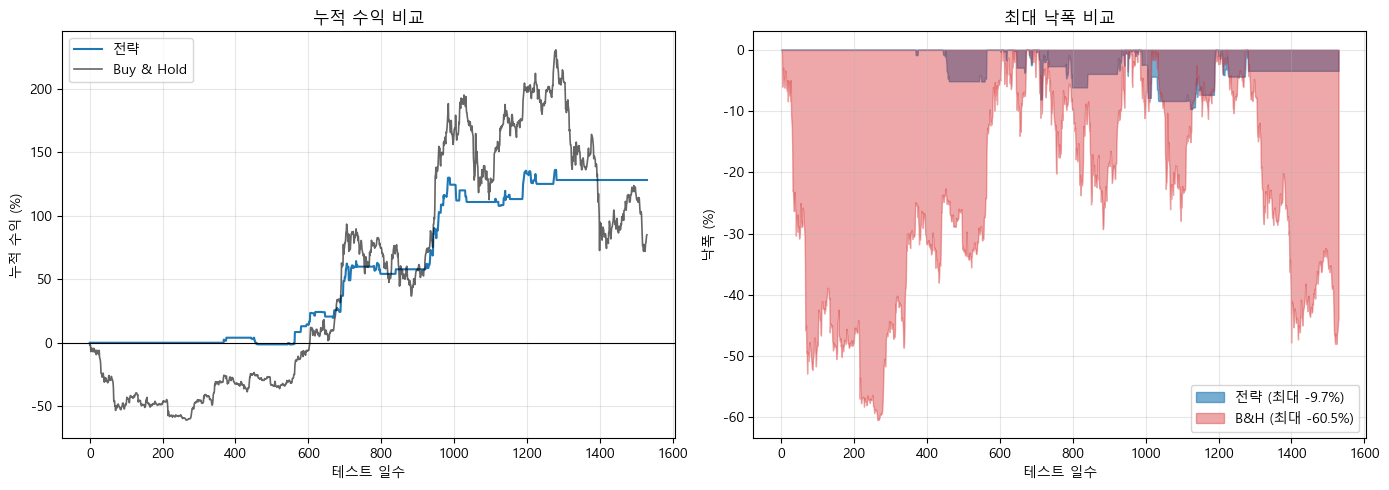


프로젝트 종료


In [90]:
# ===== 셀 7 =====
# 최종 요약

print("=" * 70)
print("최종 전략")
print("=" * 70)
print(f"""
  지표    : 온체인 {len(ONCHAIN)}개 + 거래량 {len(VOLUME)}개
  모델    : SVC (RBF, C={C_BEST}, gamma={G_BEST})
  진입    : 예측 확률 > 0.5
            AND {BEST_FILTER_NAME}
  청산    : 다음 날 종가
  비용    : 왕복 {COST_ROUND*100:.2f}% (지정가 주문)
""")

r_f = judge(P, T, R, FI, BEST_FILTER)

print("=" * 70)
print("성과")
print("=" * 70)
print(f"\n  {'':16s} {'전략':>12s} {'Buy & Hold':>14s}")
print(f"  {'-'*44}")
print(f"  {'누적 수익':16s} {r_f['cum']*100:+11.1f}% {BH['cum']*100:+13.1f}%")
print(f"  {'연평균':16s} {cagr_s*100:+11.1f}% {BH['cagr']*100:+13.1f}%")
print(f"  {'최대 낙폭':16s} {mdd_s*100:11.1f}% {BH['mdd']*100:13.1f}%")
print(f"  {'샤프 비율':16s} {sharpe_s:12.2f} {BH['sharpe']:14.2f}")
print(f"  {'거래 횟수':16s} {r_f['n']:12d} {0:14d}")
print(f"  {'승률':16s} {r_f['wr']*100:11.2f}% {'—':>14s}")
print(f"  {'손익비':16s} {r_f['pl']:12.2f} {'—':>14s}")

print("\n" + "=" * 70)
print("검증 요약")
print("=" * 70)
print(f"""
  앞뒤 승률 차이   : {abs(r_in['wr']-r_out['wr'])*100:.2f}%p
  플러스 구간      : {r_f['pos_ratio']*100:.0f}%
  상위 3건 제외    : {r_f['ex3']*100:+.1f}%
  무작위 대비      : 상위 {(1-pct)*100:.1f}%
  비용 상한        : 왕복 {max_cost*100:.2f}%
""")

# ── 최종 그래프 ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

okR = ~np.isnan(R)
s_arr = np.where(sig, R - COST_ROUND, 0.0)
eq_s = np.exp(np.nancumsum(s_arr[okR]))
eq_b = np.exp(np.nancumsum(R[okR]))

axes[0].plot(eq_s*100 - 100, lw=1.5, color="tab:blue", label="전략")
axes[0].plot(eq_b*100 - 100, lw=1.2, color="black", alpha=0.6,
             label="Buy & Hold")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_xlabel("테스트 일수")
axes[0].set_ylabel("누적 수익 (%)")
axes[0].set_title("누적 수익 비교")
axes[0].legend()
axes[0].grid(alpha=0.3)

dd_s = (eq_s / np.maximum.accumulate(eq_s) - 1) * 100
dd_b = (eq_b / np.maximum.accumulate(eq_b) - 1) * 100
axes[1].fill_between(range(len(dd_s)), dd_s, 0, alpha=0.6,
                     color="tab:blue", label=f"전략 (최대 {dd_s.min():.1f}%)")
axes[1].fill_between(range(len(dd_b)), dd_b, 0, alpha=0.4,
                     color="tab:red", label=f"B&H (최대 {dd_b.min():.1f}%)")
axes[1].set_xlabel("테스트 일수")
axes[1].set_ylabel("낙폭 (%)")
axes[1].set_title("최대 낙폭 비교")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("프로젝트 종료")
print("=" * 70)